# Balancing Cost Comparison: IV Algorithm vs Real ELEXON Costs (2024)

This notebook compares the total daily balancing costs produced by the **explicit zonal balancing market clearing algorithm** (IV extension) against the **real balancing costs** observed in the GB Balancing Mechanism (from ELEXON accepted bids and offers).

**Data sources:**
- **IV algorithm cost**: `results/{day}/IV_clearing_settlement_summary_flex.csv` → sum of `total_cost_gbp` per day
- **Real ELEXON cost**: `data/base/{day}/bids.csv` and `offers.csv` → accepted bid/offer volumes × prices × 0.5 (half-hour settlement)

**Coverage:** 363 days of IV results (missing: 2024-09-24, 2024-09-25, 2024-09-26), 364 days of real ELEXON data.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configure plot style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Paths
ROOT = Path(r"c:\GBPower")
RESULTS_DIR = ROOT / "results"
DATA_DIR = ROOT / "data" / "base"

# Build sorted list of all 2024 date folders
all_dates = sorted([d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name.startswith("2024")])
print(f"Found {len(all_dates)} result date folders (2024)")
print(f"Date range: {all_dates[0]} to {all_dates[-1]}")

Found 366 result date folders (2024)
Date range: 2024-01-01 to 2024-12-31


## Load and Aggregate Daily Balancing Costs

For each day of 2024, we compute:
- **IV algorithm cost**: Sum of `total_cost_gbp` from `IV_clearing_settlement_summary_flex.csv`
- **Real ELEXON cost**: From accepted `bids.csv` and `offers.csv` (wide-format), compute `volume × price × 0.5` per BMU per settlement period, then sum the day

Note: bid costs can be negative (when generators pay the SO to reduce output, e.g. curtailed wind with negative prices). Offer costs are always positive.

In [19]:
def compute_real_balancing_cost(day_str):
    """
    Compute real balancing cost from ELEXON accepted bids and offers.
    
    bids.csv / offers.csv format: wide table where
    - Row 0 header: BMU names as columns
    - Rows alternate: (timestamp, 'vol', v1, v2, ...) then (timestamp, 'price', p1, p2, ...)
    - Cost per cell = vol * price * 0.5 (half-hour settlement period)
    
    Returns: dict with offer_cost, bid_cost, total_cost (all in GBP)
    """
    base_path = DATA_DIR / day_str
    
    result = {'offer_cost': np.nan, 'bid_cost': np.nan, 'total_cost': np.nan}
    
    for file_type in ['offers', 'bids']:
        fpath = base_path / f"{file_type}.csv"
        if not fpath.exists():
            continue
        
        df = pd.read_csv(fpath, index_col=[0, 1])
        
        # Separate volume and price rows
        vols = df.loc[pd.IndexSlice[:, 'vol'], :]
        prices = df.loc[pd.IndexSlice[:, 'price'], :]
        
        # Align indices (drop the vol/price level)
        vols.index = vols.index.droplevel(1)
        prices.index = prices.index.droplevel(1)
        
        # Cost = vol * price * 0.5 (half-hour settlement)
        cost_matrix = vols * prices * 0.5
        total = cost_matrix.sum().sum()
        
        if file_type == 'offers':
            result['offer_cost'] = total
        else:
            result['bid_cost'] = total
    
    if not np.isnan(result['offer_cost']) or not np.isnan(result['bid_cost']):
        result['total_cost'] = np.nansum([result['offer_cost'], result['bid_cost']])
    
    return result


def compute_iv_algorithm_cost(day_str):
    """
    Compute IV algorithm total clearing cost from settlement summary.
    Returns total cost in GBP.
    """
    fpath = RESULTS_DIR / day_str / "IV_clearing_settlement_summary_flex.csv"
    if not fpath.exists():
        return np.nan
    
    df = pd.read_csv(fpath)
    return df['total_cost_gbp'].sum()


# Iterate over all days and collect results
rows = []
missing_iv = []
missing_real = []

for day in tqdm(all_dates, desc="Loading daily costs"):
    iv_cost = compute_iv_algorithm_cost(day)
    real = compute_real_balancing_cost(day)
    
    if np.isnan(iv_cost):
        missing_iv.append(day)
    if np.isnan(real['total_cost']):
        missing_real.append(day)
    
    rows.append({
        'date': pd.Timestamp(day),
        'iv_cost_gbp': iv_cost,
        'real_offer_cost_gbp': real['offer_cost'],
        'real_bid_cost_gbp': real['bid_cost'],
        'real_total_cost_gbp': real['total_cost'],
    })

df_costs = pd.DataFrame(rows).set_index('date')

print(f"\nLoaded {len(df_costs)} days")
print(f"Missing IV results: {len(missing_iv)} days — {missing_iv}")
print(f"Missing real data: {len(missing_real)} days — {missing_real}")
print(f"\nDate range: {df_costs.index.min().date()} to {df_costs.index.max().date()}")
print(f"\nFirst 5 rows:")
df_costs.head()

Loading daily costs: 100%|██████████| 366/366 [00:19<00:00, 18.91it/s]



Loaded 366 days
Missing IV results: 3 days — ['2024-09-24', '2024-09-25', '2024-09-26']
Missing real data: 3 days — ['2024-01-01', '2024-01-02', '2024-01-15']

Date range: 2024-01-01 to 2024-12-31

First 5 rows:


,iv_cost_gbp,real_offer_cost_gbp,real_bid_cost_gbp,real_total_cost_gbp
date,,,,
2024-01-01,-92319.34445,NaN,NaN,NaN
2024-01-02,182194.45860,NaN,NaN,NaN
2024-01-03,6778.95250,1.054740e+06,-223838.996755,830901.059914
2024-01-04,170562.12430,1.084312e+06,-342970.852657,741340.805557
2024-01-05,0.00000,7.403890e+05,-342426.248510,397962.718573


## Compute Cumulative and Rolling Costs

Derive additional columns for trend analysis:
- 7-day and 30-day rolling averages to smooth day-to-day noise
- Cumulative costs across the year
- Daily difference (savings = real cost − IV cost)

In [20]:
# Drop rows where either cost is missing for clean analysis
df_clean = df_costs.dropna(subset=['iv_cost_gbp', 'real_total_cost_gbp']).copy()
print(f"Clean dataset: {len(df_clean)} days with both IV and real costs")

# Convert to thousands of GBP for readability
df_clean['iv_cost_k'] = df_clean['iv_cost_gbp'] / 1e3
df_clean['real_cost_k'] = df_clean['real_total_cost_gbp'] / 1e3
df_clean['real_offer_k'] = df_clean['real_offer_cost_gbp'] / 1e3
df_clean['real_bid_k'] = df_clean['real_bid_cost_gbp'] / 1e3

# Rolling averages
df_clean['iv_roll7'] = df_clean['iv_cost_k'].rolling(7, min_periods=1).mean()
df_clean['real_roll7'] = df_clean['real_cost_k'].rolling(7, min_periods=1).mean()
df_clean['iv_roll30'] = df_clean['iv_cost_k'].rolling(30, min_periods=1).mean()
df_clean['real_roll30'] = df_clean['real_cost_k'].rolling(30, min_periods=1).mean()

# Cumulative costs
df_clean['iv_cumsum'] = df_clean['iv_cost_k'].cumsum()
df_clean['real_cumsum'] = df_clean['real_cost_k'].cumsum()

# Daily difference (positive = algorithm cheaper than real)
df_clean['savings_k'] = df_clean['real_cost_k'] - df_clean['iv_cost_k']
df_clean['savings_cumsum'] = df_clean['savings_k'].cumsum()

# Month column for aggregation
df_clean['month'] = df_clean.index.to_period('M')

print(f"\nAnnual totals:")
print(f"  IV Algorithm:  £{df_clean['iv_cost_k'].sum():,.0f}k  (£{df_clean['iv_cost_gbp'].sum()/1e6:,.2f}M)")
print(f"  Real ELEXON:   £{df_clean['real_cost_k'].sum():,.0f}k  (£{df_clean['real_total_cost_gbp'].sum()/1e6:,.2f}M)")
print(f"  Difference:    £{df_clean['savings_k'].sum():,.0f}k")

Clean dataset: 360 days with both IV and real costs

Annual totals:
  IV Algorithm:  £179,336k  (£179.34M)
  Real ELEXON:   £834,814k  (£834.81M)
  Difference:    £655,478k


## Plot 1: Daily Balancing Costs — Time Series

Top panel: raw daily costs for both approaches.  
Bottom panel: 30-day rolling average to reveal seasonal trends.

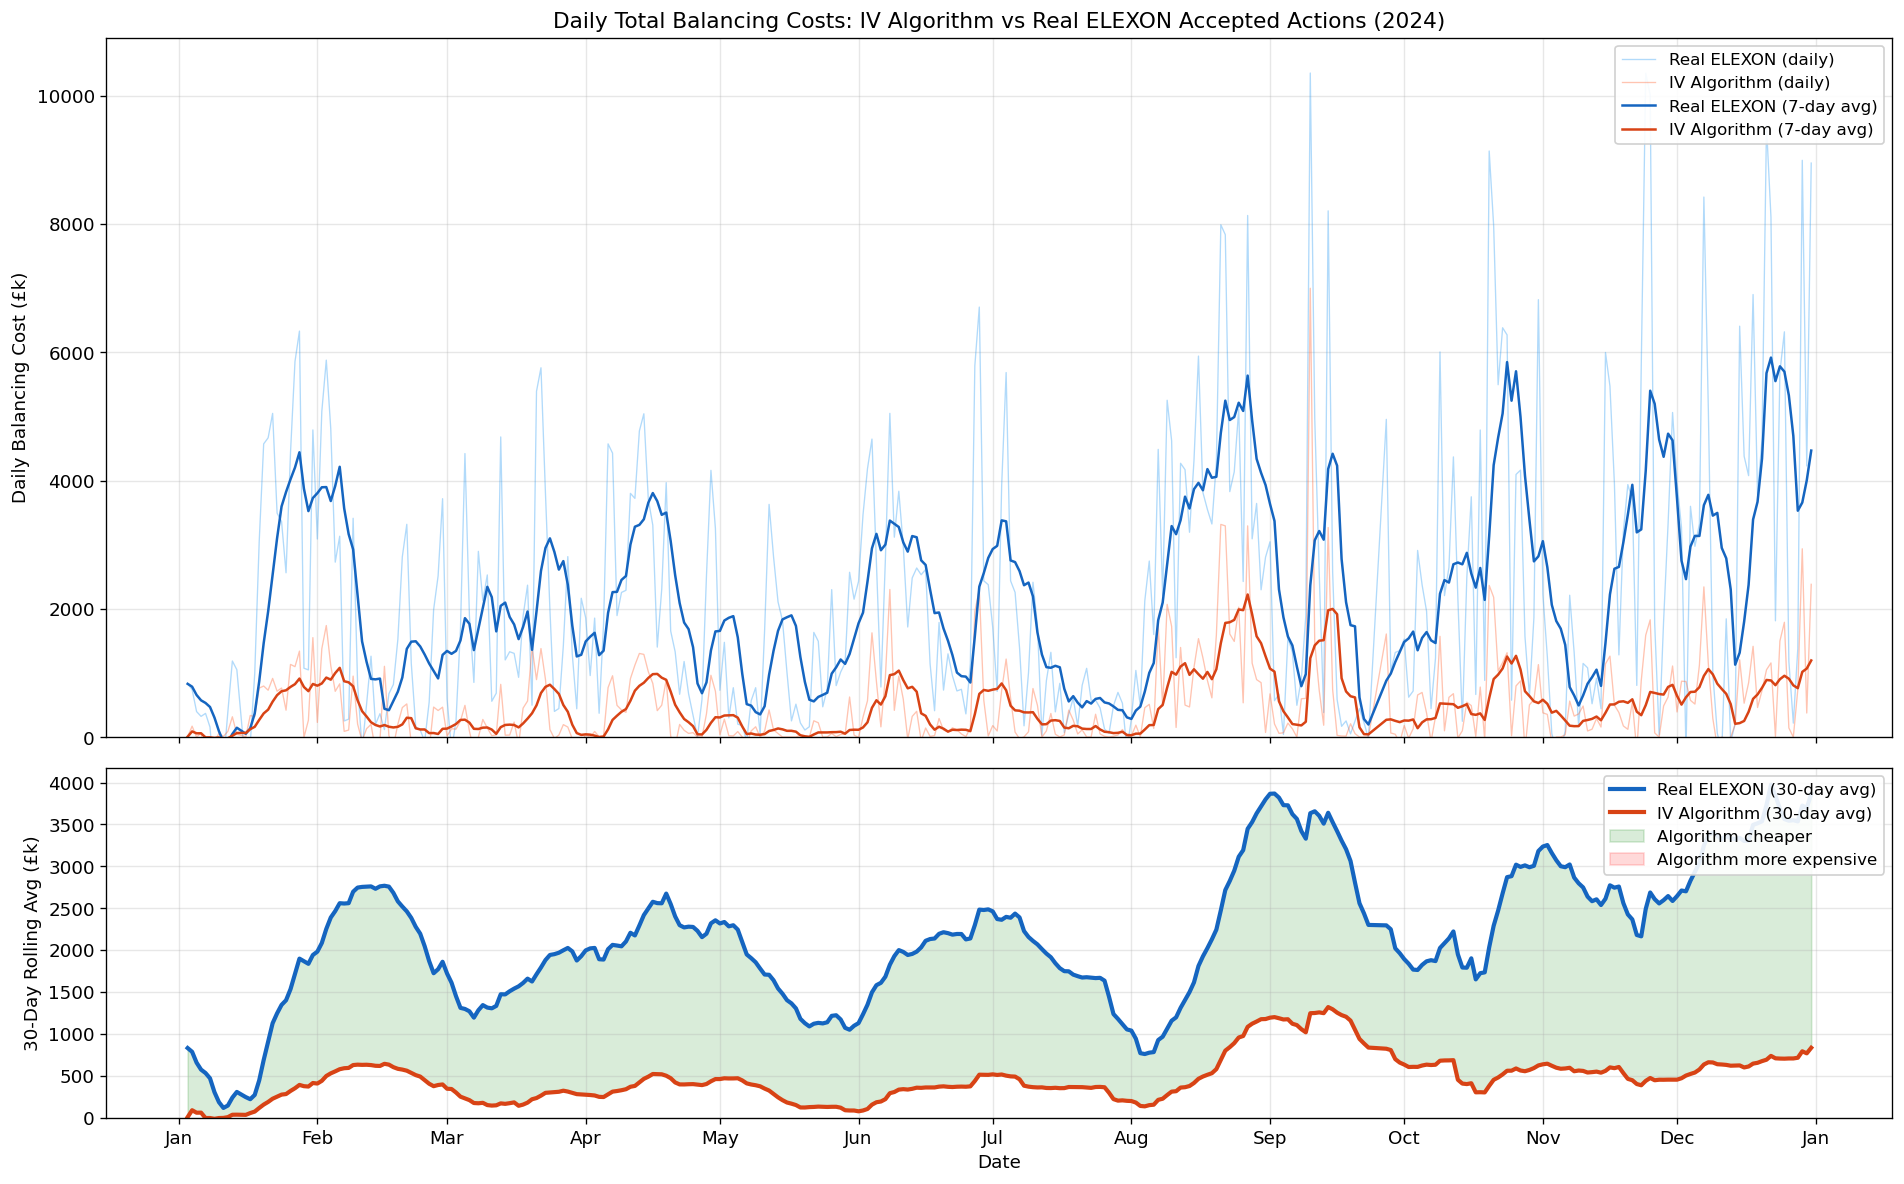

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1]})

# Top panel: raw daily costs
ax1.plot(df_clean.index, df_clean['real_cost_k'], alpha=0.35, color='#2196F3', linewidth=0.8, label='Real ELEXON (daily)')
ax1.plot(df_clean.index, df_clean['iv_cost_k'], alpha=0.35, color='#FF5722', linewidth=0.8, label='IV Algorithm (daily)')
ax1.plot(df_clean.index, df_clean['real_roll7'], color='#1565C0', linewidth=1.5, label='Real ELEXON (7-day avg)')
ax1.plot(df_clean.index, df_clean['iv_roll7'], color='#D84315', linewidth=1.5, label='IV Algorithm (7-day avg)')

ax1.set_ylabel('Daily Balancing Cost (£k)')
ax1.set_title('Daily Total Balancing Costs: IV Algorithm vs Real ELEXON Accepted Actions (2024)')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.set_ylim(bottom=0)

# Bottom panel: 30-day rolling average trend
ax2.plot(df_clean.index, df_clean['real_roll30'], color='#1565C0', linewidth=2.5, label='Real ELEXON (30-day avg)')
ax2.plot(df_clean.index, df_clean['iv_roll30'], color='#D84315', linewidth=2.5, label='IV Algorithm (30-day avg)')
ax2.fill_between(df_clean.index, df_clean['real_roll30'], df_clean['iv_roll30'], 
                  where=df_clean['real_roll30'] >= df_clean['iv_roll30'],
                  alpha=0.15, color='green', label='Algorithm cheaper')
ax2.fill_between(df_clean.index, df_clean['real_roll30'], df_clean['iv_roll30'], 
                  where=df_clean['real_roll30'] < df_clean['iv_roll30'],
                  alpha=0.15, color='red', label='Algorithm more expensive')

ax2.set_ylabel('30-Day Rolling Avg (£k)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', framealpha=0.9)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_daily_cost_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2: Monthly Aggregated Balancing Cost Comparison

Grouped bar chart comparing total monthly costs from both approaches, with percentage difference overlay.

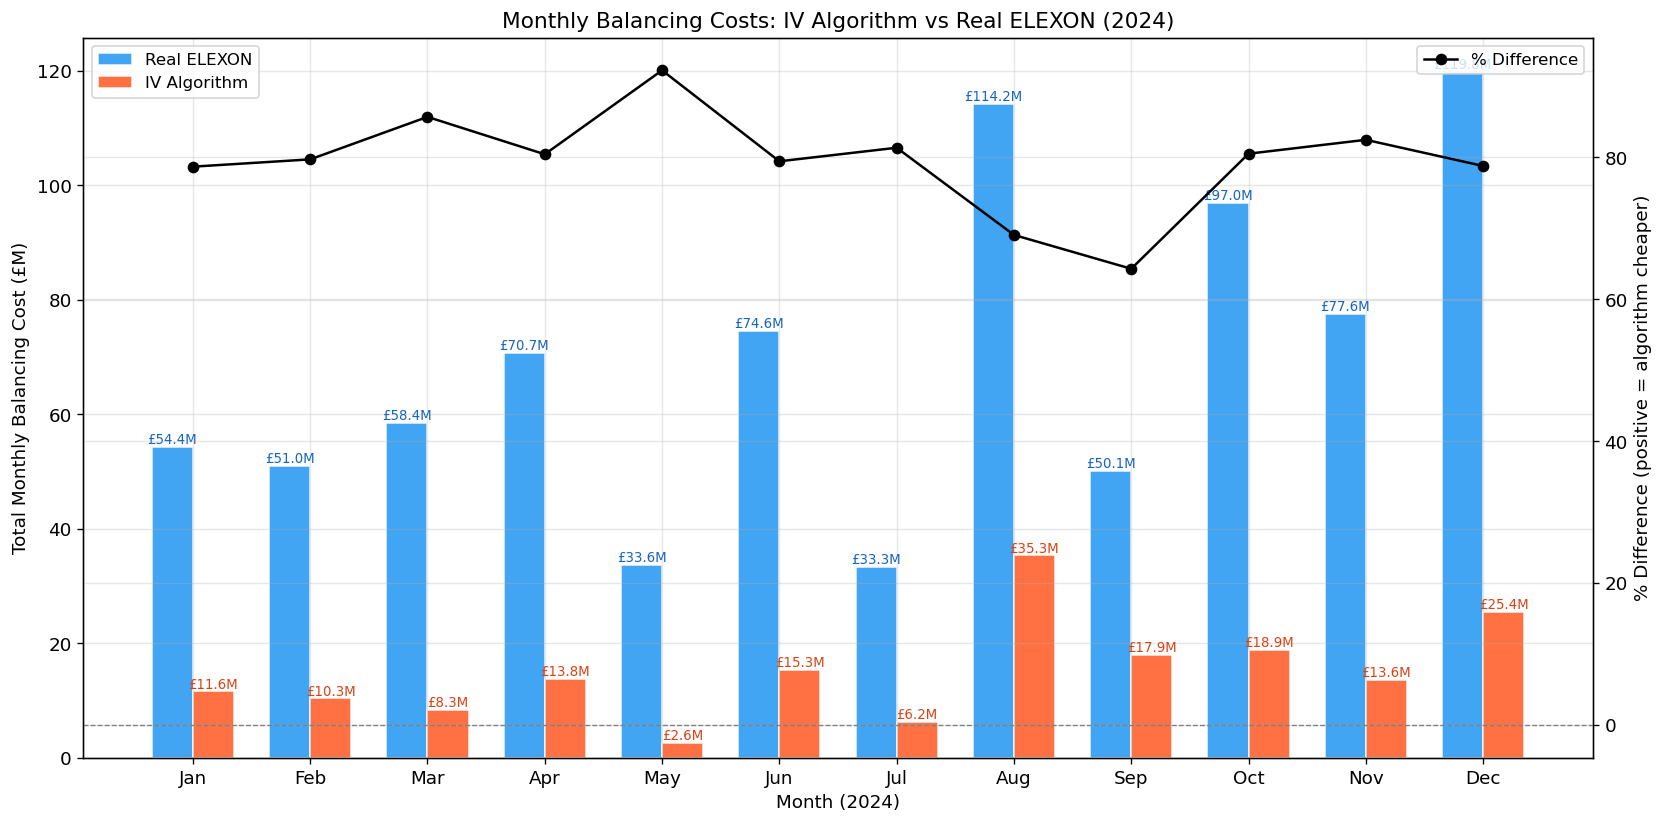


Monthly Summary:
         days  real_total_m  iv_total_m  pct_diff
month                                            
2024-01    28         54.36       11.58     78.70
2024-02    29         51.03       10.35     79.73
2024-03    31         58.43        8.35     85.72
2024-04    30         70.66       13.82     80.44
2024-05    31         33.63        2.60     92.28
2024-06    30         74.58       15.32     79.46
2024-07    31         33.31        6.21     81.37
2024-08    31        114.24       35.33     69.07
2024-09    27         50.14       17.90     64.30
2024-10    31         96.99       18.89     80.53
2024-11    30         77.58       13.59     82.48
2024-12    31        119.84       25.41     78.80


In [22]:
# Aggregate by month
monthly = df_clean.groupby('month').agg(
    iv_total=('iv_cost_gbp', 'sum'),
    real_total=('real_total_cost_gbp', 'sum'),
    days=('iv_cost_gbp', 'count'),
).copy()

monthly['iv_total_m'] = monthly['iv_total'] / 1e6
monthly['real_total_m'] = monthly['real_total'] / 1e6
monthly['pct_diff'] = (monthly['real_total'] - monthly['iv_total']) / monthly['real_total'] * 100

month_labels = [p.strftime('%b') for p in monthly.index]
x = np.arange(len(monthly))
width = 0.35

fig, ax1 = plt.subplots(figsize=(14, 7))

bars_real = ax1.bar(x - width/2, monthly['real_total_m'], width, 
                     label='Real ELEXON', color='#2196F3', alpha=0.85, edgecolor='white')
bars_iv = ax1.bar(x + width/2, monthly['iv_total_m'], width, 
                   label='IV Algorithm', color='#FF5722', alpha=0.85, edgecolor='white')

# Value labels on bars
for bar in bars_real:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'£{height:.1f}M', ha='center', va='bottom', fontsize=8, color='#1565C0')

for bar in bars_iv:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'£{height:.1f}M', ha='center', va='bottom', fontsize=8, color='#D84315')

ax1.set_xlabel('Month (2024)')
ax1.set_ylabel('Total Monthly Balancing Cost (£M)')
ax1.set_title('Monthly Balancing Costs: IV Algorithm vs Real ELEXON (2024)')
ax1.set_xticks(x)
ax1.set_xticklabels(month_labels)
ax1.legend(loc='upper left')
ax1.set_ylim(bottom=0)

# Percentage difference line on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, monthly['pct_diff'], 'ko-', markersize=6, linewidth=1.5, label='% Difference')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('% Difference (positive = algorithm cheaper)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_monthly_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print monthly table
print("\nMonthly Summary:")
print(monthly[['days', 'real_total_m', 'iv_total_m', 'pct_diff']].to_string(float_format='{:.2f}'.format))

## Plot 3: Daily Cost Difference (Savings) with Cumulative Trend

Positive bars (green) = days where the IV algorithm is cheaper than reality.  
Negative bars (red) = days where the IV algorithm is more expensive.  
The black line shows cumulative savings over the year.

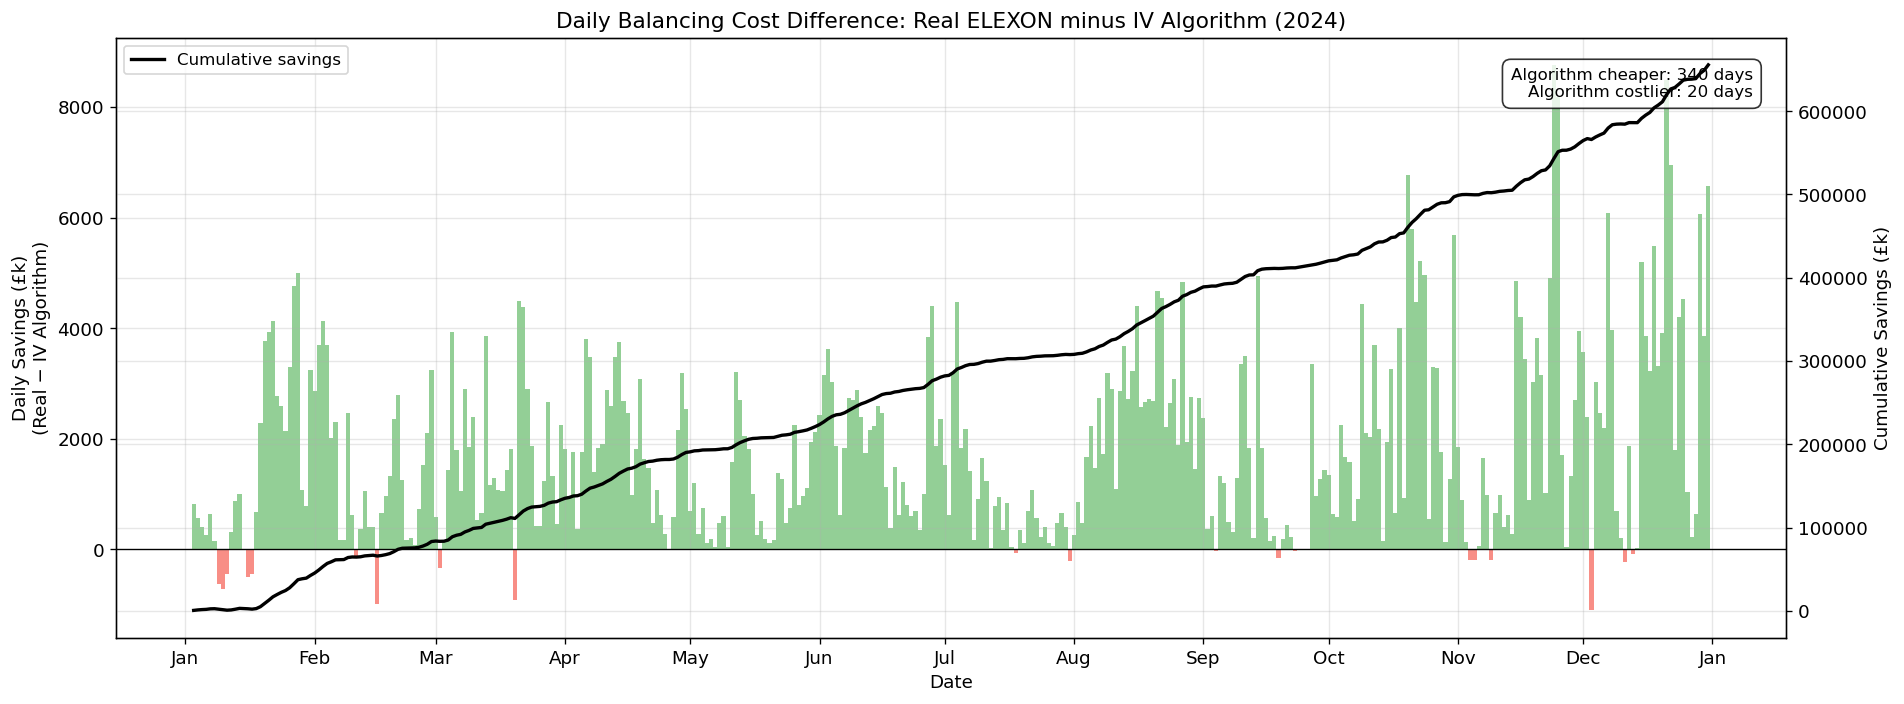

In [23]:
fig, ax1 = plt.subplots(figsize=(16, 6))

colors = ['#4CAF50' if s >= 0 else '#F44336' for s in df_clean['savings_k']]
ax1.bar(df_clean.index, df_clean['savings_k'], color=colors, alpha=0.6, width=1.0, edgecolor='none')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_ylabel('Daily Savings (£k)\n(Real − IV Algorithm)')
ax1.set_title('Daily Balancing Cost Difference: Real ELEXON minus IV Algorithm (2024)')

# Cumulative savings on secondary axis
ax2 = ax1.twinx()
ax2.plot(df_clean.index, df_clean['savings_cumsum'], color='black', linewidth=2, label='Cumulative savings')
ax2.set_ylabel('Cumulative Savings (£k)')
ax2.legend(loc='upper left')

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.set_xlabel('Date')

# Count days
n_cheaper = (df_clean['savings_k'] > 0).sum()
n_expensive = (df_clean['savings_k'] < 0).sum()
ax1.text(0.98, 0.95, f'Algorithm cheaper: {n_cheaper} days\nAlgorithm costlier: {n_expensive} days',
         transform=ax1.transAxes, ha='right', va='top', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_daily_savings.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4: Scatter — IV Algorithm Cost vs Real ELEXON Cost

Each point is one day. The dashed 45° line marks where costs are equal. Points below the line = algorithm cheaper.

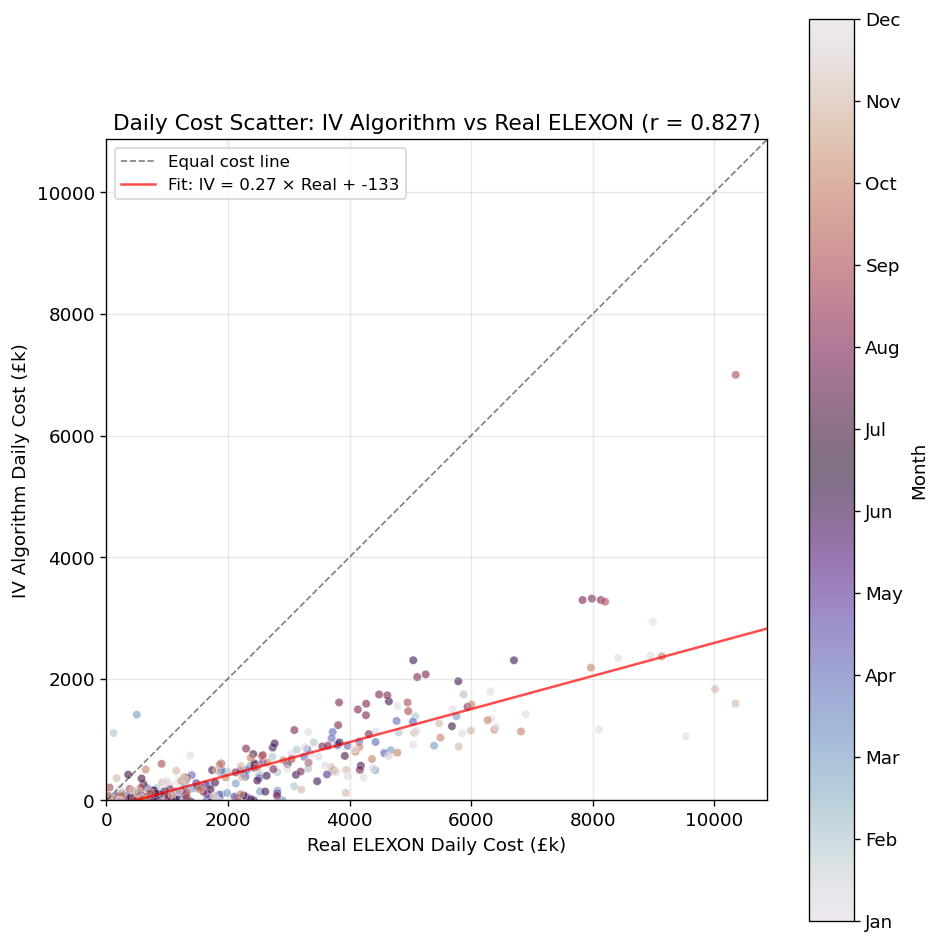

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

# Color by month for seasonal context
month_num = df_clean.index.month
scatter = ax.scatter(df_clean['real_cost_k'], df_clean['iv_cost_k'], 
                      c=month_num, cmap='twilight', alpha=0.6, s=25, edgecolors='white', linewidth=0.3)

# 45-degree reference line
max_val = max(df_clean['real_cost_k'].max(), df_clean['iv_cost_k'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, alpha=0.5, label='Equal cost line')

# Regression line
from numpy.polynomial import polynomial as P
mask = ~(df_clean['real_cost_k'].isna() | df_clean['iv_cost_k'].isna())
coeffs = np.polyfit(df_clean.loc[mask, 'real_cost_k'], df_clean.loc[mask, 'iv_cost_k'], 1)
x_fit = np.linspace(0, max_val, 100)
ax.plot(x_fit, np.polyval(coeffs, x_fit), 'r-', linewidth=1.5, alpha=0.7, 
        label=f'Fit: IV = {coeffs[0]:.2f} × Real + {coeffs[1]:.0f}')

# Correlation
corr = df_clean['real_cost_k'].corr(df_clean['iv_cost_k'])

ax.set_xlabel('Real ELEXON Daily Cost (£k)')
ax.set_ylabel('IV Algorithm Daily Cost (£k)')
ax.set_title(f'Daily Cost Scatter: IV Algorithm vs Real ELEXON (r = {corr:.3f})')
ax.legend(loc='upper left')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal')

# Colorbar for month
cbar = plt.colorbar(scatter, ax=ax, label='Month', ticks=range(1, 13))
cbar.ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'IV_fig_cost_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics

Key metrics comparing the two approaches over the full year.

In [25]:
# Summary statistics
stats = {
    'Total IV Algorithm Cost (£M)': df_clean['iv_cost_gbp'].sum() / 1e6,
    'Total Real ELEXON Cost (£M)': df_clean['real_total_cost_gbp'].sum() / 1e6,
    'Total Difference (£M)': df_clean['savings_k'].sum() / 1e3,
    'Mean Daily IV Cost (£k)': df_clean['iv_cost_k'].mean(),
    'Mean Daily Real Cost (£k)': df_clean['real_cost_k'].mean(),
    'Mean Daily Difference (£k)': df_clean['savings_k'].mean(),
    'Median Daily Difference (£k)': df_clean['savings_k'].median(),
    'Std Dev Daily Difference (£k)': df_clean['savings_k'].std(),
    '% Difference (annual)': (df_clean['real_total_cost_gbp'].sum() - df_clean['iv_cost_gbp'].sum()) / df_clean['real_total_cost_gbp'].sum() * 100,
    'Days Algorithm Cheaper': int((df_clean['savings_k'] > 0).sum()),
    'Days Algorithm Costlier': int((df_clean['savings_k'] < 0).sum()),
    'Days Equal (±£1k)': int((df_clean['savings_k'].abs() <= 1).sum()),
    'Max Daily Saving (£k)': df_clean['savings_k'].max(),
    'Max Daily Excess Cost (£k)': df_clean['savings_k'].min(),
    'Pearson Correlation': df_clean['real_cost_k'].corr(df_clean['iv_cost_k']),
    'Days Analysed': len(df_clean),
}

summary_df = pd.DataFrame.from_dict(stats, orient='index', columns=['Value'])
summary_df['Value'] = summary_df['Value'].apply(lambda x: f'{x:,.2f}' if isinstance(x, float) else str(x))
print(summary_df.to_string())

                                   Value
Total IV Algorithm Cost (£M)      179.34
Total Real ELEXON Cost (£M)       834.81
Total Difference (£M)             655.48
Mean Daily IV Cost (£k)           498.16
Mean Daily Real Cost (£k)       2,318.93
Mean Daily Difference (£k)      1,820.77
Median Daily Difference (£k)    1,442.04
Std Dev Daily Difference (£k)   1,650.47
% Difference (annual)              78.52
Days Algorithm Cheaper            340.00
Days Algorithm Costlier            20.00
Days Equal (±£1k)                   0.00
Max Daily Saving (£k)           8,761.12
Max Daily Excess Cost (£k)     -1,102.69
Pearson Correlation                 0.83
Days Analysed                     360.00
